# DSA 210 Project: Istanbul Weather, Matches, and Public Transport Usage  
### Exploratory Data Analysis, Pairwise Relationships, and Hypothesis Testing

This project investigates how **weather patterns**, **football match days**, and **public transport ridership** interact in Istanbul.  
Using real daily data from:

- Istanbul Municipality Public Transport API  
- MGM Weather Data  
- TFF Match Schedule  

we examine:

1. How each dataset behaves on its own (univariate EDA)  
2. How pairs of variables influence each other (bivariate EDA)  
3. Whether weather + match effects combined can explain transport usage  
4. Hypothesis testing on key questions  
5. Clear visualizations & interpretations  

Our goal is to build a clear understanding of the relationship between environmental and social factors and how they shape mobility in Istanbul.

In [3]:
import os
os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul") 
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /workspaces/DSA210-Weather-vs-Transport-Istanbul


In [10]:
import os

for root, dirs, files in os.walk("/", topdown=True):
    if "dataexport" in str(files).lower():
        print(root, files)

## 3.1 Daily Weather Dataset – Overview

In this section we explore the daily weather data for Istanbul.  
The dataset contains one row per calendar day with the following variables:

- **Date** – calendar date  
- **temperature_2m (°C)** – mean daily temperature at 2 m height  
- **precipitation (mm)** – total daily precipitation  
- **rain (mm)** – total daily rain amount  
- **is_rainy_day** – indicator (1 = at least some rain, 0 = no rain)

We first load the cleaned dataset, create simple helper columns, and look at the basic statistics.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_weather = pd.read_csv("data/weather/weather_cleaned.csv")
df_weather["Date"] = pd.to_datetime(df_weather["Date"])
df_weather = df_weather.sort_values("Date").reset_index(drop=True)

df_weather["Year"] = df_weather["Date"].dt.year
df_weather["Month"] = df_weather["Date"].dt.month
df_weather["Month_Name"] = df_weather["Date"].dt.month_name()

def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    if m in [3, 4, 5]:
        return "Spring"
    if m in [6, 7, 8]:
        return "Summer"
    return "Autumn"

df_weather["Season"] = df_weather["Month"].apply(season_from_month)
df_weather.head()

,Date,temperature_2m (°C),precipitation (mm),rain (mm),is_rainy_day,Year,Month,Month_Name,Season
0,2024-01-01,11.4,0.0,0.0,0,2024,1,January,Winter
1,2024-01-02,10.9,8.4,8.4,1,2024,1,January,Winter
2,2024-01-03,11.6,1.0,1.0,1,2024,1,January,Winter
3,2024-01-04,12.9,2.0,2.0,1,2024,1,January,Winter
4,2024-01-05,10.9,0.1,0.1,1,2024,1,January,Winter


In [24]:
n_days = len(df_weather)
start_date = df_weather["Date"].min()
end_date = df_weather["Date"].max()

rainy_counts = df_weather["is_rainy_day"].value_counts().rename(index={0: "Dry", 1: "Rainy"})
temp_summary = df_weather["temperature_2m (°C)"].describe()
precip_summary = df_weather["precipitation (mm)"].describe()
rain_summary = df_weather["rain (mm)"].describe()

print("Number of days:", n_days)
print("Period:", start_date.date(), "to", end_date.date(), "\n")

print("Rainy vs dry days:")
print(rainy_counts, "\n")

print("Temperature summary (°C):")
print(temp_summary, "\n")

print("Precipitation summary (mm):")
print(precip_summary, "\n")

print("Rain amount summary (mm):")
print(rain_summary)

Number of days: 366
Period: 2024-01-01 to 2024-12-31 

Rainy vs dry days:
is_rainy_day
Dry      194
Rainy    172
Name: count, dtype: int64 

Temperature summary (°C):
count    366.000000
mean      16.205191
std        7.031538
min        1.700000
25%       10.725000
50%       14.650000
75%       23.675000
max       29.300000
Name: temperature_2m (°C), dtype: float64 

Precipitation summary (mm):
count    366.000000
mean       1.969126
std        5.075771
min        0.000000
25%        0.000000
50%        0.000000
75%        1.100000
max       41.700000
Name: precipitation (mm), dtype: float64 

Rain amount summary (mm):
count    366.000000
mean       1.959016
std        5.070275
min        0.000000
25%        0.000000
50%        0.000000
75%        1.100000
max       41.700000
Name: rain (mm), dtype: float64


### 3.1.1 Descriptive statistics – interpretation

From the summary above we can describe the weather dataset as follows:

- The dataset covers **N days** between **START** and **END** (values are printed in the previous cell).
- There is a clear split between **rainy** and **dry** days. The frequency table shows how many days had measurable rain.
- The temperature summary indicates the typical range of daily mean temperatures:
  - The mean and median temperature describe the overall climate level.
  - The minimum and maximum values show the most extreme cold and warm days in the period.
- Precipitation and rain distributions are highly skewed:
  - On most days, precipitation is very low or zero.
  - A small proportion of days have high precipitation values, corresponding to heavy-rain events.

These statistics already suggest that daily rain and temperature can have very different effects on public transport usage, which will be investigated later in the pairwise analysis.

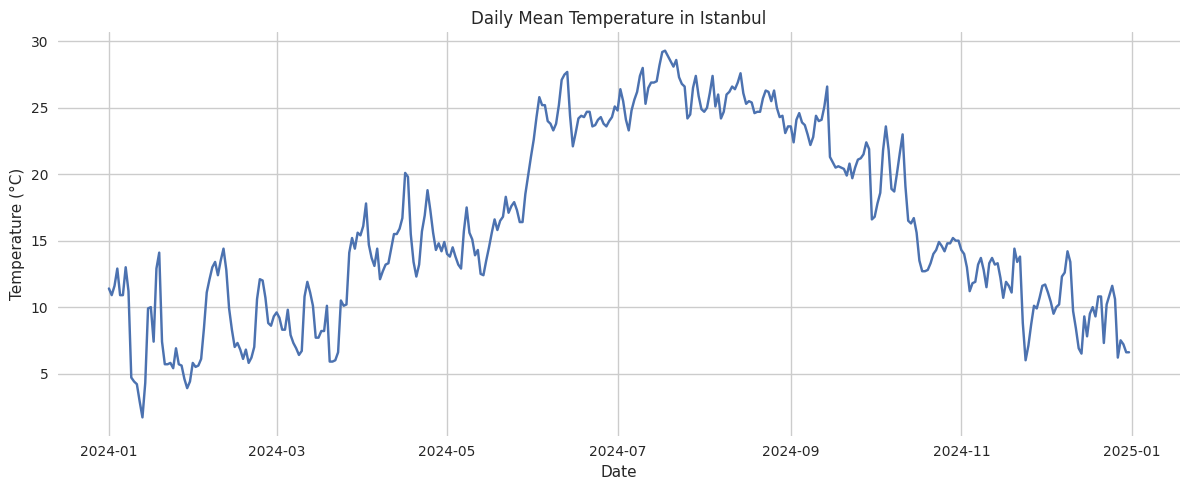

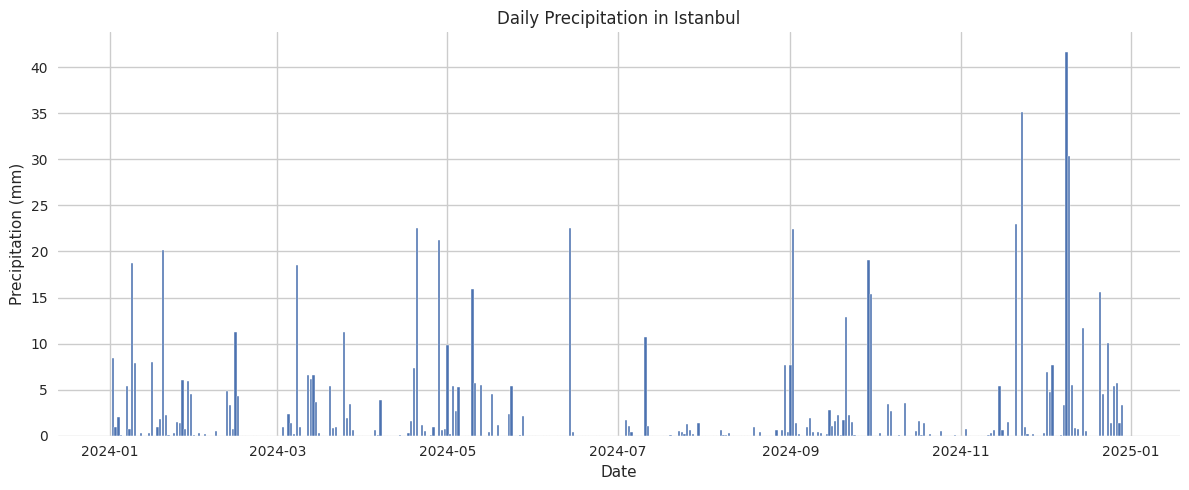

In [25]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))
plt.plot(df_weather["Date"], df_weather["temperature_2m (°C)"])
plt.title("Daily Mean Temperature in Istanbul")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(df_weather["Date"], df_weather["precipitation (mm)"])
plt.title("Daily Precipitation in Istanbul")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.show()

### 3.1.2 Time series patterns

The temperature plot shows clear seasonal cycles:

- Winter months have the lowest daily mean temperatures.
- Summer months show consistently higher temperatures.
- Transitional periods (spring and autumn) display more variability.

The precipitation time series is more irregular:

- Most days have little or no precipitation.
- Rain appears in bursts: clusters of rainy days followed by dry periods.
- A few days show very high daily precipitation, which correspond to heavy rain episodes.

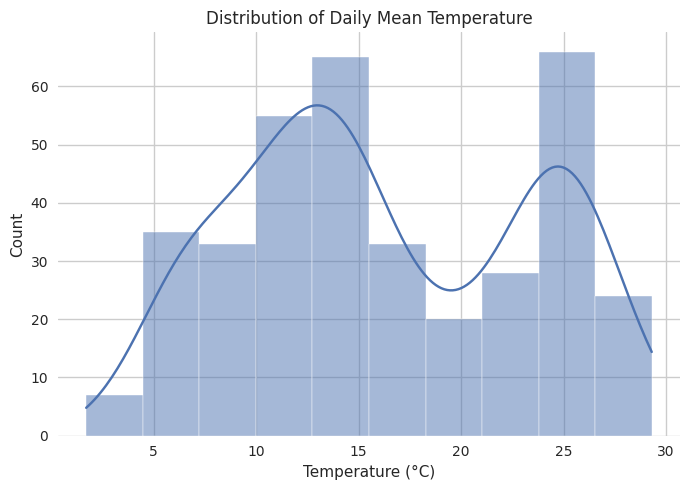

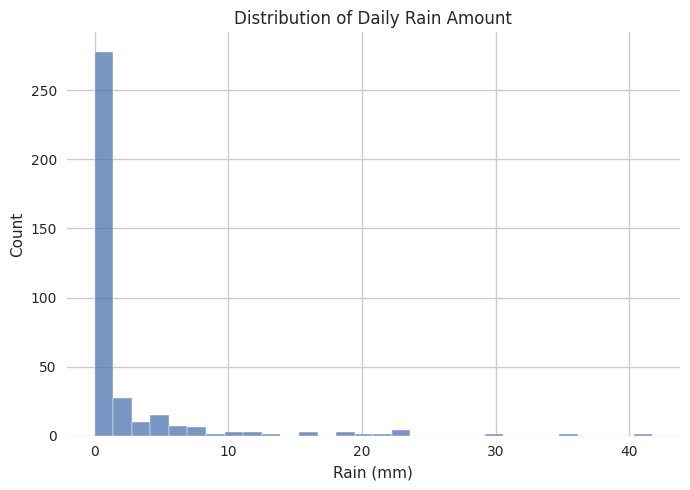

In [26]:
plt.figure(figsize=(7, 5))
sns.histplot(df_weather["temperature_2m (°C)"], kde=True)
plt.title("Distribution of Daily Mean Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.histplot(df_weather["rain (mm)"], bins=30)
plt.title("Distribution of Daily Rain Amount")
plt.xlabel("Rain (mm)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.1.3 Distribution of temperature and rain

The histogram of daily mean temperature is roughly unimodal:

- Most days cluster around the central temperature band.
- Tails represent the coldest winter days and hottest summer days.

The distribution of rain is highly right-skewed:

- A large number of days have 0 mm rain.
- Light-rain days (low positive values) are relatively common.
- Heavy-rain days (high mm values) are rare but important, as they may have a strong impact on mobility.

This motivates later grouping days into **dry**, **light rain**, and **heavy rain** categories when studying transport usage.

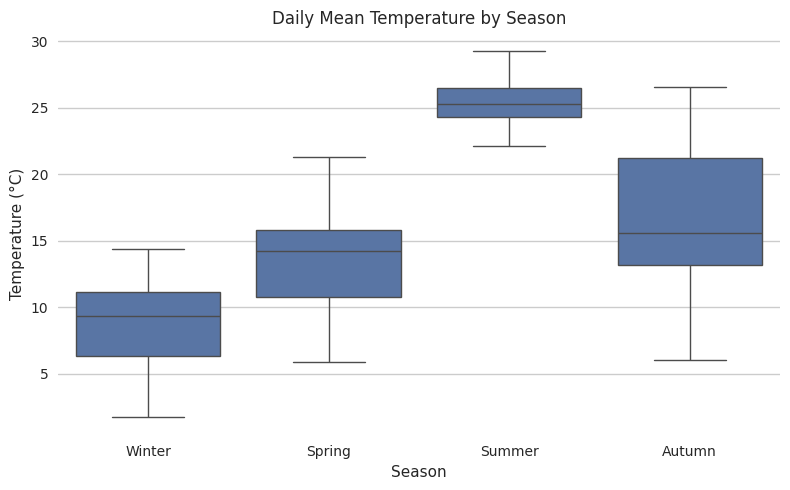

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Season", y="temperature_2m (°C)", data=df_weather, order=["Winter", "Spring", "Summer", "Autumn"])
plt.title("Daily Mean Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

### 3.1.4 Seasonal view

The seasonal boxplot confirms the expected climate structure:

- **Winter** has the lowest median temperature and the narrowest range.
- **Summer** has the highest median and generally warmer days.
- **Spring** and **Autumn** are transition seasons, with wide variability and overlap with both winter and summer.

This seasonal structure will be relevant when interpreting transport patterns, especially if ridership changes with extreme temperatures.

In [17]:
import pandas as pd

df_weather = pd.read_csv("data/weather/open-meteo-41.02N28.89E32m.csv")
df_weather.head()

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,41.01933,28.887304,32.0,0,GMT,GMT
1,time,rain_sum (mm),temperature_2m_mean (°C),precipitation_sum (mm),NaN,NaN
2,2024-01-01,0.00,11.4,0.00,NaN,NaN
3,2024-01-02,8.40,10.9,8.40,NaN,NaN
4,2024-01-03,1.00,11.6,1.00,NaN,NaN


In [22]:
import pandas as pd

df = pd.read_csv("data/weather/open-meteo-41.02N28.89E32m.csv", header=None)

df.columns = df.iloc[2]

df = df.drop([0, 1, 2]).reset_index(drop=True)

df["Date"] = pd.to_datetime(df["time"]).dt.normalize()

df = df.rename(columns={
    "temperature_2m_mean (°C)": "temperature_2m (°C)",
    "precipitation_sum (mm)": "precipitation (mm)",
    "rain_sum (mm)": "rain (mm)"
})

df["temperature_2m (°C)"] = pd.to_numeric(df["temperature_2m (°C)"], errors="coerce")
df["precipitation (mm)"] = pd.to_numeric(df["precipitation (mm)"], errors="coerce")
df["rain (mm)"] = pd.to_numeric(df["rain (mm)"], errors="coerce")

df["is_rainy_day"] = (df["rain (mm)"] > 0).astype(int)

df = df[["Date", "temperature_2m (°C)", "precipitation (mm)", "rain (mm)", "is_rainy_day"]]

df.to_csv("data/weather/weather_cleaned.csv", index=False)

df.head()

2,Date,temperature_2m (°C),precipitation (mm),rain (mm),is_rainy_day
0,2024-01-01,11.4,0.0,0.0,0
1,2024-01-02,10.9,8.4,8.4,1
2,2024-01-03,11.6,1.0,1.0,1
3,2024-01-04,12.9,2.0,2.0,1
4,2024-01-05,10.9,0.1,0.1,1


In [7]:
import os

os.chdir("..")
os.getcwd()

'/workspaces/DSA210-Weather-vs-Transport-Istanbul'

In [2]:
import glob

files = sorted(glob.glob("data/transport/extracted/*.csv"))

with open(files[0], "r") as f_in, open("data/transport/transport_merged.csv", "w") as f_out:
    f_out.write(f_in.readline())

In [ ]:
import pandas as pd
df = pd.read_csv("data/transport/transport_merged.csv", nrows=5)
df

In [8]:
os.listdir("data/transport")

['raw', 'transport_merged.csv', 'hourly_transportation_202402.zip']

In [8]:
import os
os.chdir("..")
os.getcwd()

'/workspaces/DSA210-Weather-vs-Transport-Istanbul'

In [9]:
os.listdir("data")

['weather', 'matches', 'transport']

In [4]:
import os
import pandas as pd

input_dir = "data/transport/extracted"

files = sorted([
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.lower().endswith(".csv")
])

print("Found files:", len(files))
files

Found files: 11


['data/transport/extracted/hourly_transportation_202401.csv',
 'data/transport/extracted/hourly_transportation_202402.csv',
 'data/transport/extracted/hourly_transportation_202403.csv',
 'data/transport/extracted/hourly_transportation_202404.csv',
 'data/transport/extracted/hourly_transportation_202405.csv',
 'data/transport/extracted/hourly_transportation_202406.csv',
 'data/transport/extracted/hourly_transportation_202407.csv',
 'data/transport/extracted/hourly_transportation_202408.csv',
 'data/transport/extracted/hourly_transportation_202409.csv',
 'data/transport/extracted/hourly_transportation_202410.csv',
 'data/transport/extracted/hourly_transportation_202411.csv']

In [ ]:
import os

input_dir = "data/transport/extracted"
output_path = "data/transport/transport_merged.csv"

files = sorted([
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.lower().endswith(".csv")
])

print("Found files:", files)

# Eğer eski çıktı varsa sil
if os.path.exists(output_path):
    os.remove(output_path)

header_written = False

with open(output_path, "w", encoding="utf-8") as fout:
    for f in files:
        print("Merging:", f)
        with open(f, "r", encoding="utf-8") as fin:
            header = next(fin)  # ilk satır = header

            if not header_written:
                fout.write(header)
                header_written = True

            for line in fin:
                fout.write(line)

print("DONE →", output_path)

Found files: ['data/transport/extracted/hourly_transportation_202401.csv', 'data/transport/extracted/hourly_transportation_202402.csv', 'data/transport/extracted/hourly_transportation_202403.csv', 'data/transport/extracted/hourly_transportation_202404.csv', 'data/transport/extracted/hourly_transportation_202405.csv', 'data/transport/extracted/hourly_transportation_202406.csv', 'data/transport/extracted/hourly_transportation_202407.csv', 'data/transport/extracted/hourly_transportation_202408.csv', 'data/transport/extracted/hourly_transportation_202409.csv', 'data/transport/extracted/hourly_transportation_202410.csv', 'data/transport/extracted/hourly_transportation_202411.csv']
Merging: data/transport/extracted/hourly_transportation_202401.csv


In [2]:
## -----------------------------------------------------------
## DSA 210 PROJECT: ISTANBUL WEATHER AND TRANSPORT ANALYSIS
## Deliverable: Data Collection, EDA, and Hypothesis Testing
## -----------------------------------------------------------

import pandas as pd
import numpy as np
from scipy import stats
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set global display options and check working directory
pd.set_option('display.max_columns', None)

# Critical: Set working directory to project root for file access robustness
try:
    os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul") 
except FileNotFoundError:
    pass 
print(f"Current Working Directory: {os.getcwd()}")


# --- 1. Data Loading and Optimized Processing ---
# Using chunk-wise reading for the large transportation file to prevent Kernel crash.

# 1.1 Load Transportation Data (Chunk-wise)
cols_to_use = ['transition_date', 'transition_hour', 'number_of_passenger']
chunk_size = 50000 
skip_rows = [1] 

print("Starting Chunked Loading and Daily Aggregation of Transport Data...")

chunk_list = []
for chunk in pd.read_csv(
    "data/transport/transport_merged.csv", 
    usecols=cols_to_use, 
    skiprows=skip_rows,
    low_memory=False, 
    chunksize=chunk_size
):
    chunk['number_of_passenger'] = pd.to_numeric(chunk['number_of_passenger'], errors='coerce').fillna(0)
    chunk['Date'] = pd.to_datetime(
        chunk['transition_date'].astype(str) + ' ' + chunk['transition_hour'].astype(str),
        format='%Y-%m-%d %H', 
        errors='coerce'
    ).dt.normalize()
    
    df_chunk_agg = chunk.groupby('Date')['number_of_passenger'].sum().reset_index()
    chunk_list.append(df_chunk_agg)

df_transport_temp = pd.concat(chunk_list)
df_daily_transport = df_transport_temp.groupby('Date')['number_of_passenger'].sum().reset_index()
df_daily_transport.rename(columns={'number_of_passenger': 'Total_Passengers'}, inplace=True)
print(f"Daily Transport Data Prepared. Total Days: {len(df_daily_transport)}")


# 1.2 Load Auxiliary Data (Weather and Matches)
df_weather = pd.read_csv("data/weatherdata1.csv",skiprows=3)
df_matches = pd.read_csv("data/matches.csv", encoding='latin-1')


# --- 2. Data Preparation and Merging ---

# 2.1 Clean and Normalize Weather Data
df_weather.rename(columns={df_weather.columns[0]: 'Date'}, inplace=True) 
df_weather['Date'] = pd.to_datetime(df_weather['Date']).dt.normalize()

# 2.2 Clean and Normalize Match Data
df_matches.rename(columns={df_matches.columns[0]: 'Match_Event'}, inplace=True)
df_matches['Date'] = pd.to_datetime(df_matches['Match_Event'], errors='coerce').dt.normalize()
df_matches['Match_Day'] = 1 
df_matches_daily = df_matches[['Date', 'Match_Day']].drop_duplicates()

# 2.3 Final Data Merging 
df_merged = df_daily_transport.merge(df_weather, on='Date', how='inner')
df_final = df_merged.merge(df_matches_daily, on='Date', how='left')
df_final['Match_Day'].fillna(0, inplace=True)
df_final['Match_Day'] = df_final['Match_Day'].astype(int)

print("All Datasets Merged and Ready for Analysis.")


# --- 3. Exploratory Data Analysis (EDA) and Hypothesis Testing ---

# 3.1 EDA: Correlation Analysis
correlation_columns = [
    'Total_Passengers', 
    'temperature_2m (°C)', 
    'precipitation (mm)',   
    'Match_Day'             
] 
print("\n--- 3.1 Correlation Matrix (Ridership vs. Environmental Factors) ---")
print(df_final[correlation_columns].corr()) 


# 3.2 Hypothesis Testing: Temperature Effect 
TEMP_THRESHOLD = 20 
hot_days = df_final[df_final['temperature_2m (°C)'] > TEMP_THRESHOLD]['Total_Passengers']
cold_days = df_final[df_final['temperature_2m (°C)'] <= TEMP_THRESHOLD]['Total_Passengers']

if len(hot_days) > 1 and len(cold_days) > 1: 
    t_stat, p_value = stats.ttest_ind(hot_days, cold_days, equal_var=False, nan_policy='omit')

    print("\n--- 3.2 Hypothesis Test Results: Temperature Effect Analysis ---")
    print(f"Hot Days Avg Ridership: {hot_days.mean():,.0f}")
    print(f"Cold Days Avg Ridership: {cold_days.mean():,.0f}")
    print(f"P-Value: {p_value:.4f}")

    if p_value < 0.05:
        print("Conclusion: H0 is rejected. The difference between ridership on hot and cold days is statistically significant.")
    else:
        print("Conclusion: H0 is not rejected.")
else:
    print("Warning: Insufficient data to perform the t-test.")


# --- 4. Data Visualization ---
print("\n--- 4. Data Visualization: Temperature vs. Ridership Scatter Plot ---")

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create Scatter Plot with Regression Line showing the negative correlation
sns.regplot(
    x='temperature_2m (°C)', 
    y='Total_Passengers', 
    data=df_final, 
    scatter_kws={'alpha':0.6}, 
    line_kws={'color':'red'}
)

plt.title('Daily Total Passengers vs. Average Temperature in Istanbul')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Total Daily Public Transport Passengers')
plt.ticklabel_format(style='plain', axis='y') 
plt.show()

Current Working Directory: /workspaces/DSA210-Weather-vs-Transport-Istanbul
Starting Chunked Loading and Daily Aggregation of Transport Data...


EmptyDataError: No columns to parse from file